# Кластеризация ЕГЭ (4 если сделаны все задачи)

Рядом лежат данные с координатами точек. Везде используется Евклидово расстояние. Кластером считается набор не менее чем из 30 точек связанных друг с другом. Аномалия это точка находящаяся на расстоянии более 1 от любого кластера.

* Постройте Распределение точек
* Напишите руками DBSCAN и обработайте им все файлы
* Файл 0.xls также решите руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Отметьте Аномалии отдельным цветом
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите два числа - Среднее абсцисс и ординат центроидов кластеров * 100000

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors



def build(df):
    plt.figure(figsize=(10, 8))
    plt.scatter(df['X'], df['Y'], s=30, alpha=0.7)
    plt.title('Исходное распределение точек')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()
def euclidean_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def find_neighbors(points, point_idx, eps):
    neighbors = []
    for i in range(len(points)):
        if i != point_idx:
            dist = euclidean_distance(points[point_idx], points[i])
            if dist <= eps:
                neighbors.append(i)
    return neighbors

def dbscann(points, eps=1.0, min_pts=30):
    n_points = len(points)
    labels = np.full(n_points, -1)
    cluster_id = 0
    
    for i in range(n_points):
        if labels[i] != -1:
            continue
        neighbors = find_neighbors(points, i, eps)
        if len(neighbors) < min_pts - 1:

            labels[i] = -2
            continue
        cluster_id += 1
        labels[i] = cluster_id
        seeds = neighbors.copy()
        j = 0
        while j < len(seeds):
            current_point = seeds[j]
            
            if labels[current_point] == -2: 
                labels[current_point] = cluster_id
            elif labels[current_point] != -1:
                j += 1
                continue

            current_neighbors = find_neighbors(points, current_point, eps)
            
            if len(current_neighbors) >= min_pts - 1:

                for neighbor in current_neighbors:
                    if labels[neighbor] == -1 or labels[neighbor] == -2:
                        if neighbor not in seeds:
                            seeds.append(neighbor)
            labels[current_point] = cluster_id
            j += 1
    
    return labels
def find_centroid_point(points_cluster):
    n = len(points_cluster)
    if n == 0:
        return None
    
    min_avg_dist = float('inf')
    centroid_idx = 0
    
    for i in range(n):
        total_dist = 0
        for j in range(n):
            if i != j:
                total_dist += euclidean_distance(points_cluster[i], points_cluster[j])
        avg_dist = total_dist / (n - 1) if n > 1 else 0
        if avg_dist < min_avg_dist:
            min_avg_dist = avg_dist
            centroid_idx = i
    return points_cluster[centroid_idx]

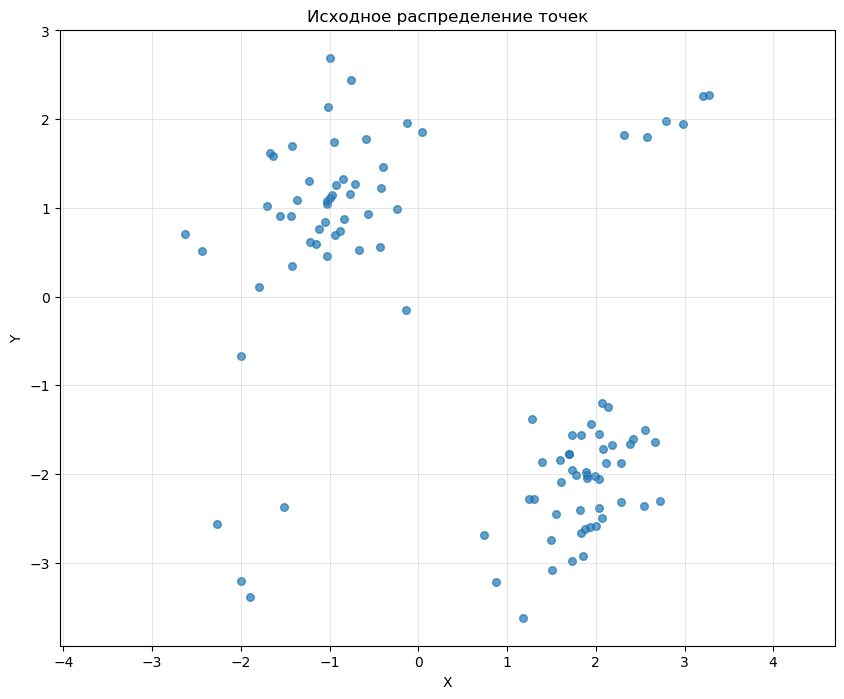

In [58]:
df = pd.read_excel('0.xls')
build(df)
points = df[['X', 'Y']].values

labels = dbscann(points, eps=1.0, min_pts=30)
unique_labels = np.unique(labels[labels >= 1])
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -2)

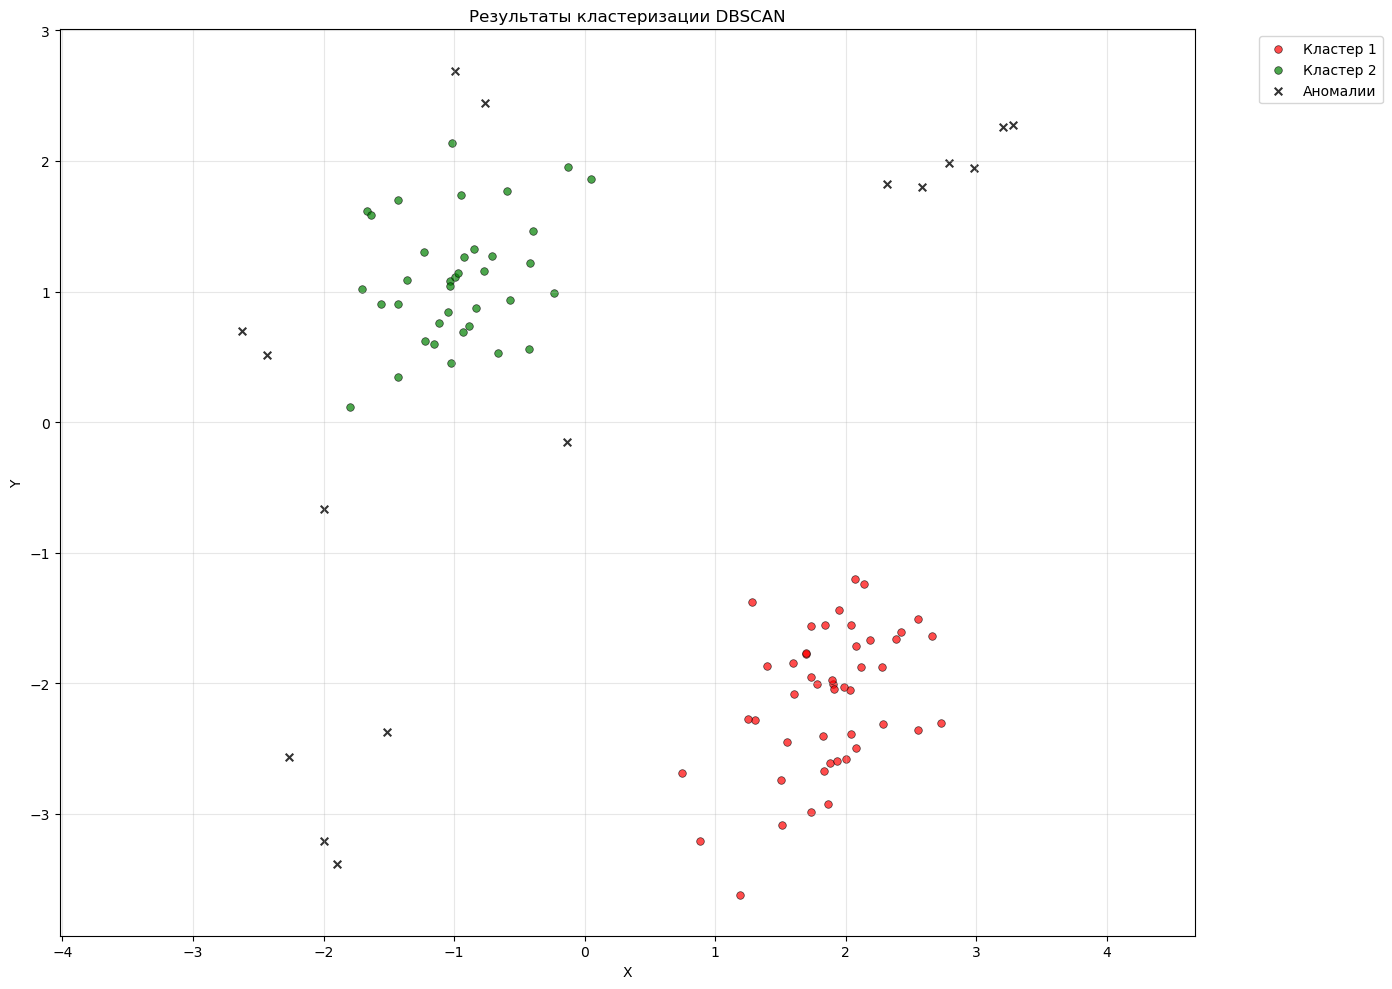

In [59]:

colors = ['red', 'green', 'orange']
color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(unique_labels)}

plt.figure(figsize=(14, 10))

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=[color_map[cluster_id]], s=30, alpha=0.7, 
                label=f'Кластер {cluster_id}', edgecolors='black', linewidth=0.5)

anomaly_points = points[labels == -2]
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            c='black', s=30, marker='x', alpha=0.8, 
            label='Аномалии')
plt.title('Результаты кластеризации DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [60]:

centroids = []
centroid_points = []

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    centroid = find_centroid_point(cluster_points)
    centroids.append(centroid)
    centroid_points.append(centroid)
    print(f"Кластер {cluster_id}: центроид = ({centroid[0]:.6f}, {centroid[1]:.6f})")

centroids_array = np.array(centroids)
mean_x = np.mean(centroids_array[:, 0])
mean_y = np.mean(centroids_array[:, 1])
result_x = mean_x * 100000
result_y = mean_y * 100000
print(f"Среднее абсцисс центроидов: {result_x:.2f}")
print(f"Среднее ординат центроидов: {result_y:.2f}")

Кластер 1: центроид = (1.905466, -2.040852)
Кластер 2: центроид = (-0.994833, 1.114112)
Среднее абсцисс центроидов: 45531.63
Среднее ординат центроидов: -46336.99


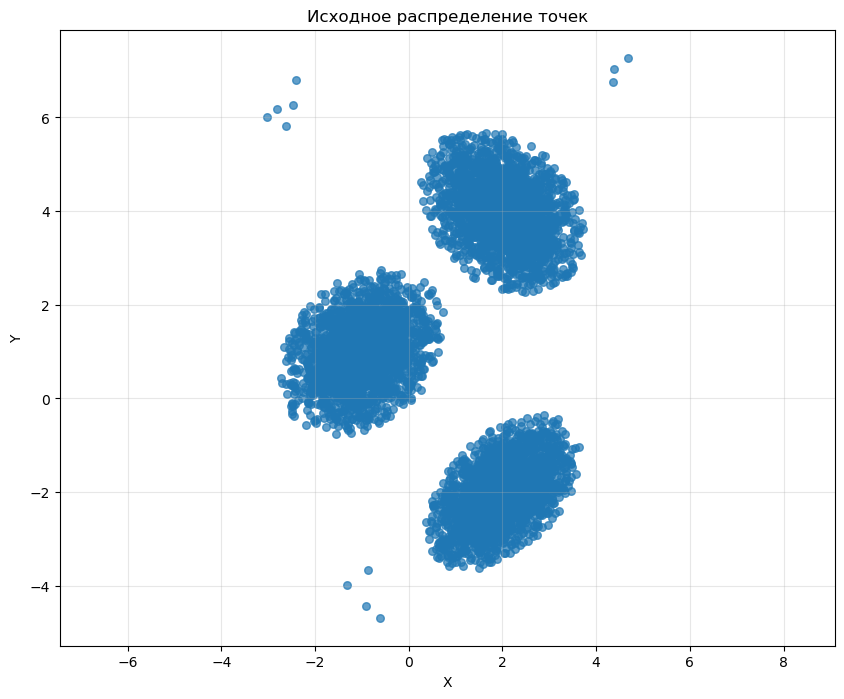

In [61]:
df = pd.read_excel('1.xls')
build(df)

points = df[['X', 'Y']].values

labels = dbscann(points, eps=0.8, min_pts=30)


unique_labels = np.unique(labels[labels >= 1])
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -2)


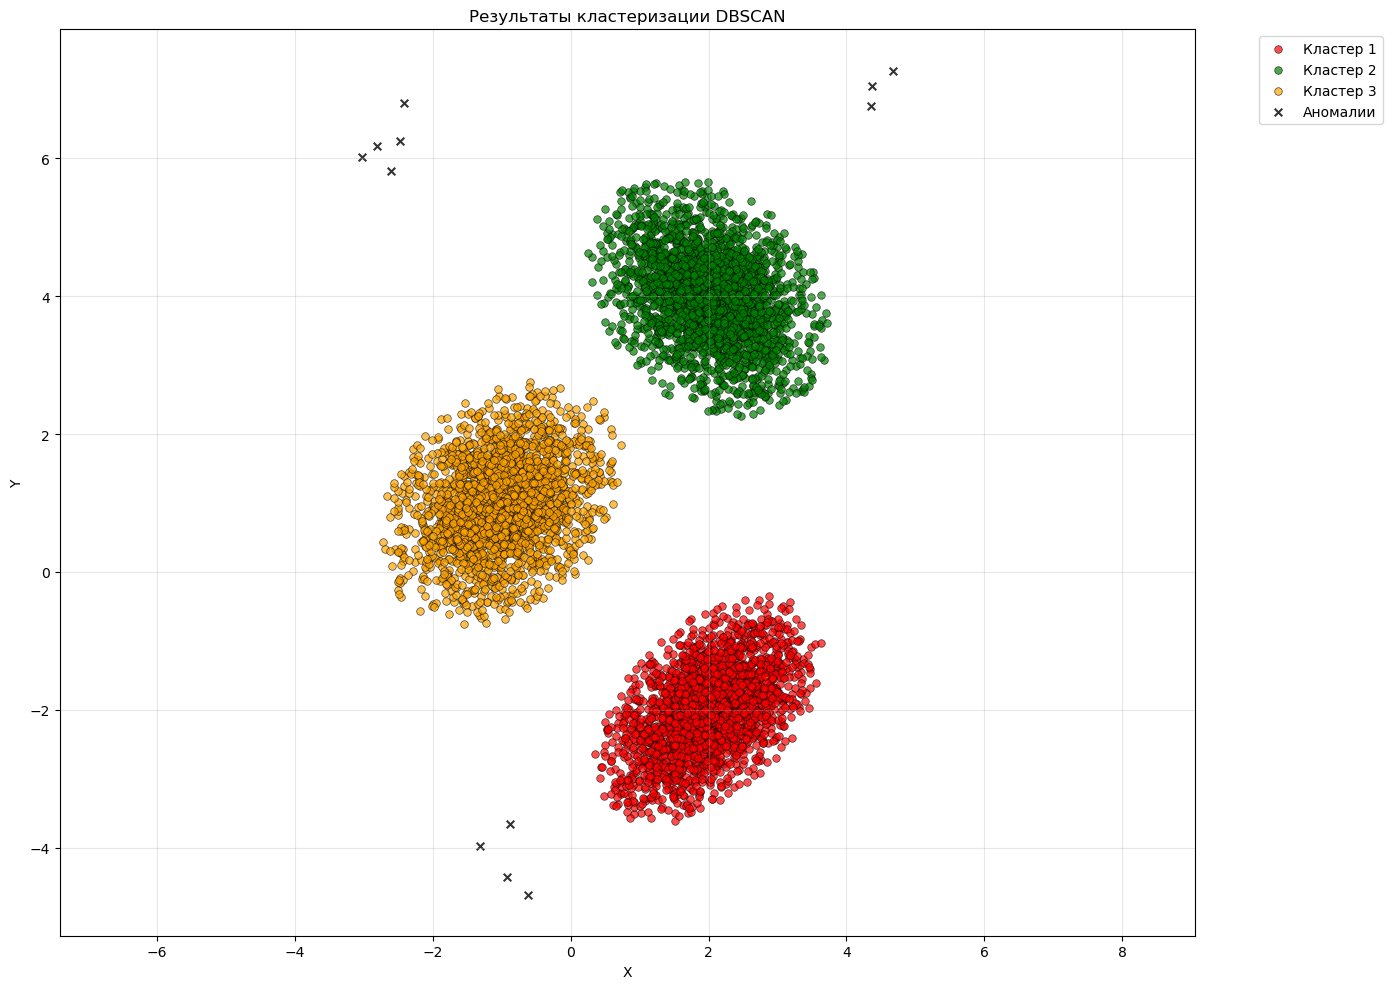

In [63]:

colors = ['red', 'green', 'orange']
color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(unique_labels)}

plt.figure(figsize=(14, 10))

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=[color_map[cluster_id]], s=30, alpha=0.7, 
                label=f'Кластер {cluster_id}', edgecolors='black', linewidth=0.5)

anomaly_points = points[labels == -2]
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            c='black', s=30, marker='x', alpha=0.8, 
            label='Аномалии')
plt.title('Результаты кластеризации DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [64]:

centroids = []
centroid_points = []

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    centroid = find_centroid_point(cluster_points)
    centroids.append(centroid)
    centroid_points.append(centroid)
    print(f"Кластер {cluster_id}: центроид = ({centroid[0]:.6f}, {centroid[1]:.6f})")


Кластер 1: центроид = (1.997911, -1.999164)
Кластер 2: центроид = (2.001615, 3.998195)
Кластер 3: центроид = (-1.002671, 1.003715)


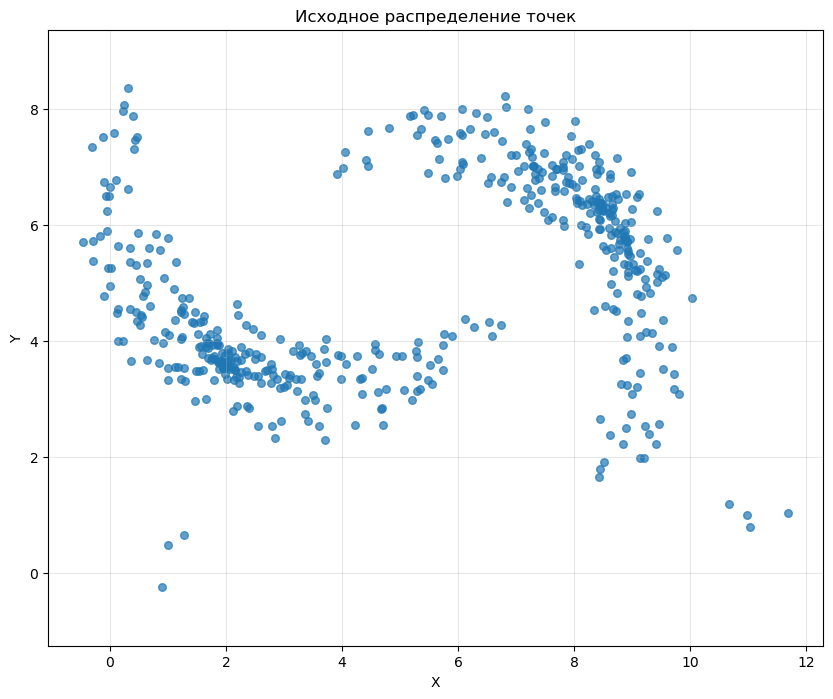

In [65]:
df = pd.read_csv('2.txt')
build(df)
points = df[['X, 'Y']].values

labels = dbscann(points, eps=1, min_pts=30)
unique_labels = np.unique(labels[labels >= 1]) 
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -2)

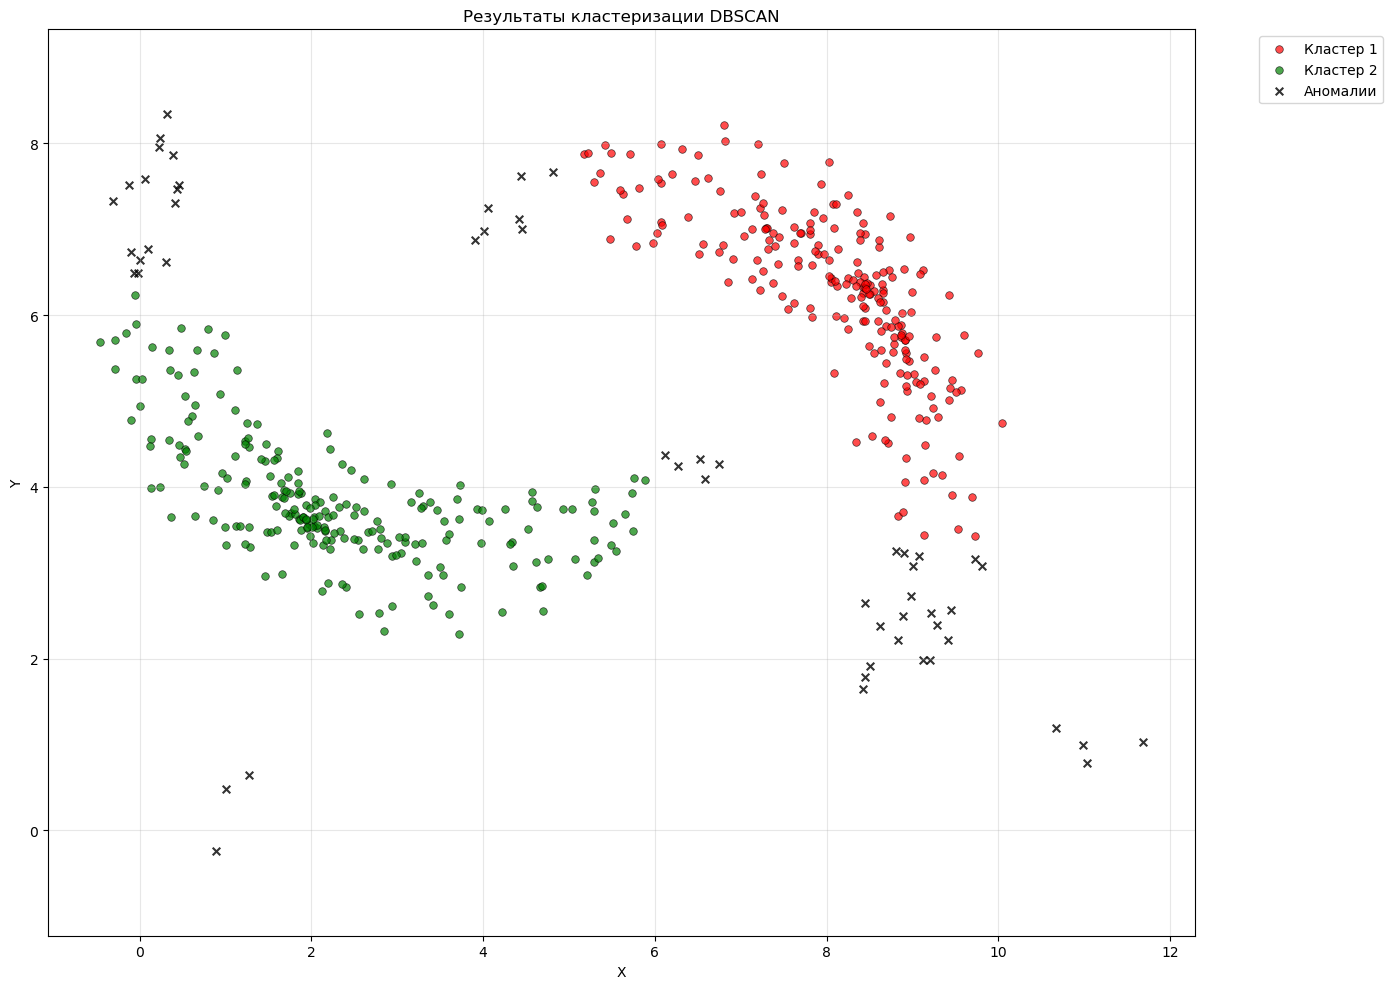

In [66]:

colors = ['red', 'green', 'orange']
color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(unique_labels)}

plt.figure(figsize=(14, 10))

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=[color_map[cluster_id]], s=30, alpha=0.7, 
                label=f'Кластер {cluster_id}', edgecolors='black', linewidth=0.5)

anomaly_points = points[labels == -2]
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            c='black', s=30, marker='x', alpha=0.8, 
            label='Аномалии')

plt.title('Результаты кластеризации DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [15]:

centroids = []
centroid_points = []

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    centroid = find_centroid_point(cluster_points)
    centroids.append(centroid)
    centroid_points.append(centroid)
    print(f"Кластер {cluster_id}: центроид = ({centroid[0]:.6f}, {centroid[1]:.6f})")

centroids_array = np.array(centroids)
mean_x = np.mean(centroids_array[:, 0])
mean_y = np.mean(centroids_array[:, 1])
result_x = mean_x * 100000
result_y = mean_y * 100000
print(f"Среднее абсцисс центроидов: {result_x:.2f}")
print(f"Среднее ординат центроидов: {result_y:.2f}")

Кластер 1: центроид = (8.226880, 6.357382)
Кластер 2: центроид = (2.090889, 3.663257)
Среднее абсцисс центроидов: 515888.41
Среднее ординат центроидов: 501031.97


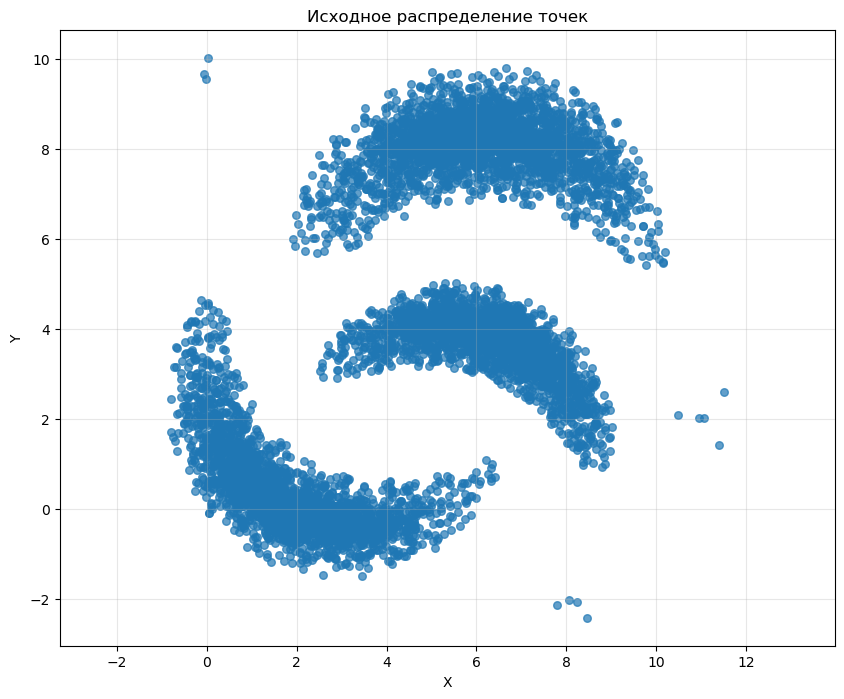

In [16]:
df = pd.read_csv('3.txt')
build(df)




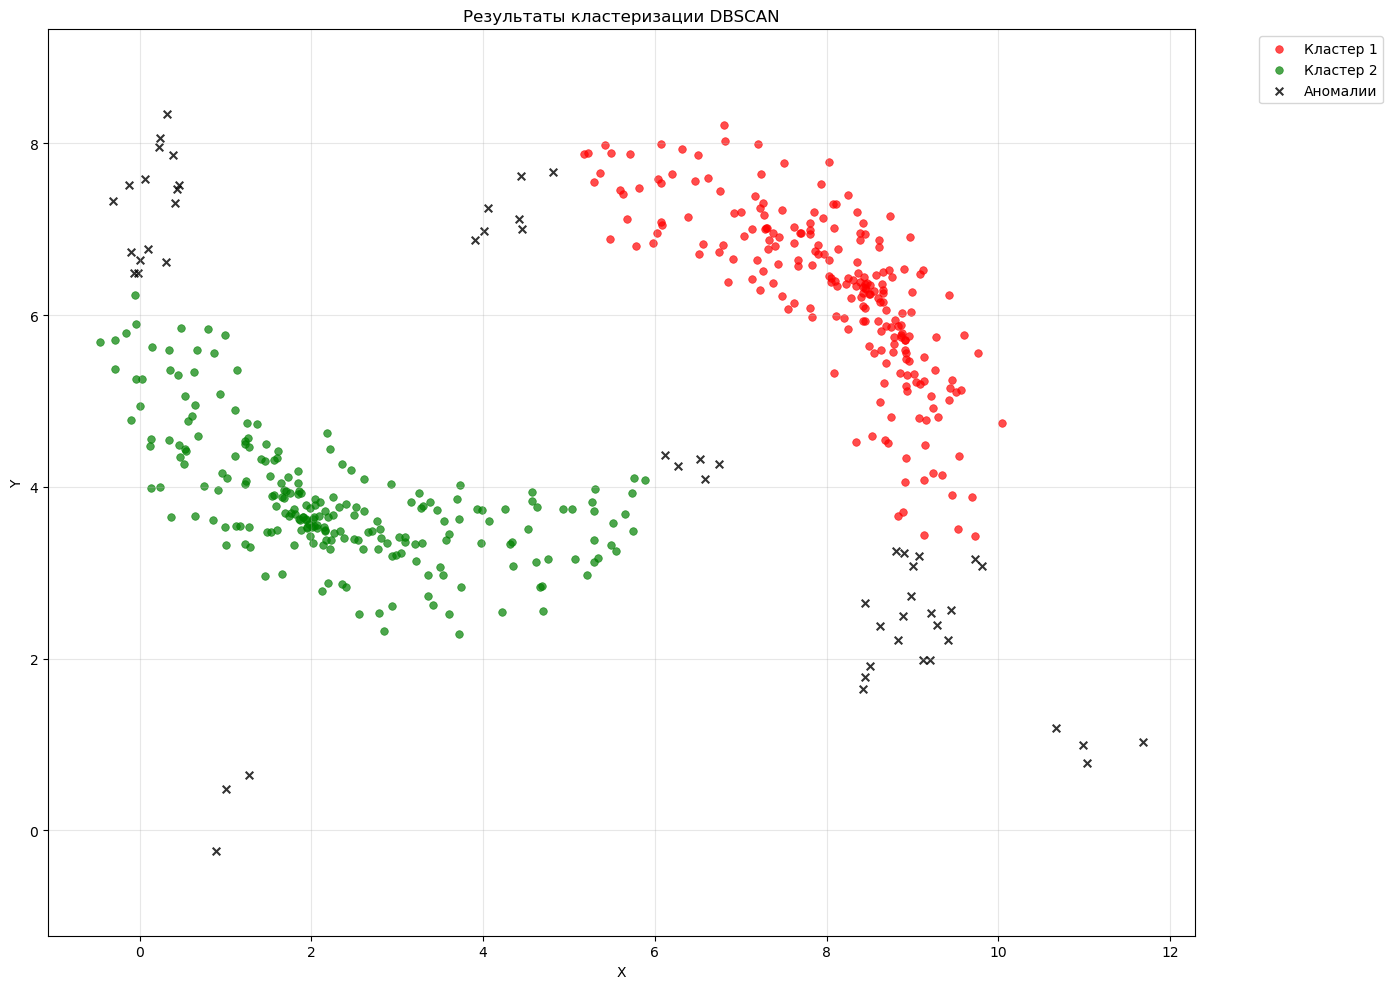

In [67]:
points = df[['X', 'Y']].values

labels = dbscann(points, eps=1, min_pts=30)


unique_labels = np.unique(labels[labels >= 1]) 
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -2)
colors = ['red', 'green', 'orange']
color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(unique_labels)}

plt.figure(figsize=(14, 10))

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=[color_map[cluster_id]], s=30, alpha=0.7, 
                label=f'Кластер {cluster_id}', linewidth=0.5)

anomaly_points = points[labels == -2]
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            c='black', s=30, marker='x', alpha=0.8, 
            label='Аномалии')
plt.title('Результаты кластеризации DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [68]:

centroids = []
centroid_points = []

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    centroid = find_centroid_point(cluster_points)
    centroids.append(centroid)
    centroid_points.append(centroid)
    print(f"Кластер {cluster_id}: центроид = ({centroid[0]:.6f}, {centroid[1]:.6f})")

centroids_array = np.array(centroids)
mean_x = np.mean(centroids_array[:, 0])
mean_y = np.mean(centroids_array[:, 1])
result_x = mean_x * 100000
result_y = mean_y * 100000
print(f"Среднее абсцисс центроидов: {result_x:.2f}")
print(f"Среднее ординат центроидов: {result_y:.2f}")

Кластер 1: центроид = (8.226880, 6.357382)
Кластер 2: центроид = (2.090889, 3.663257)
Среднее абсцисс центроидов: 515888.41
Среднее ординат центроидов: 501031.97


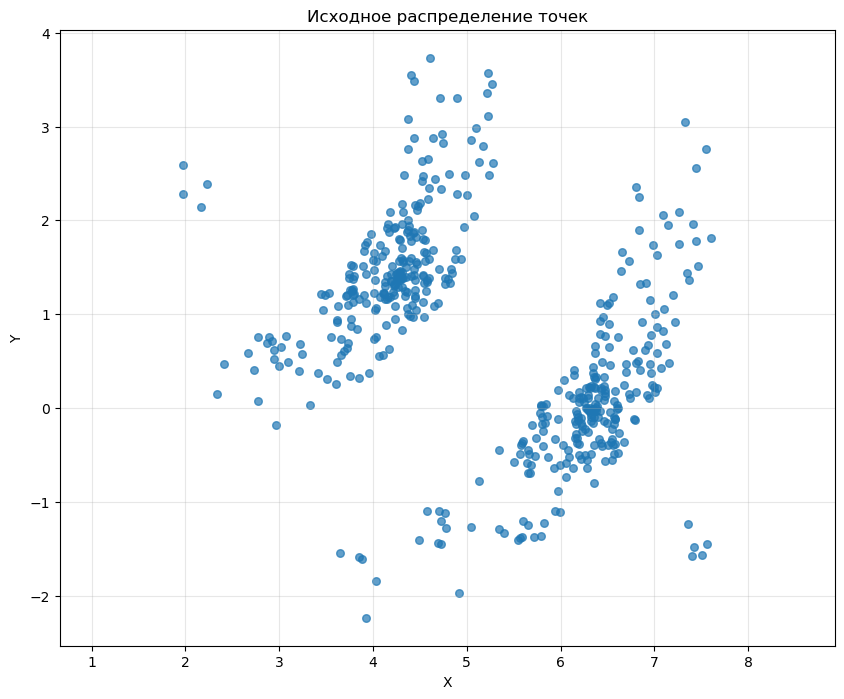

In [73]:
df = pd.read_csv('4.txt', names=['X', 'Y'])
build(df)

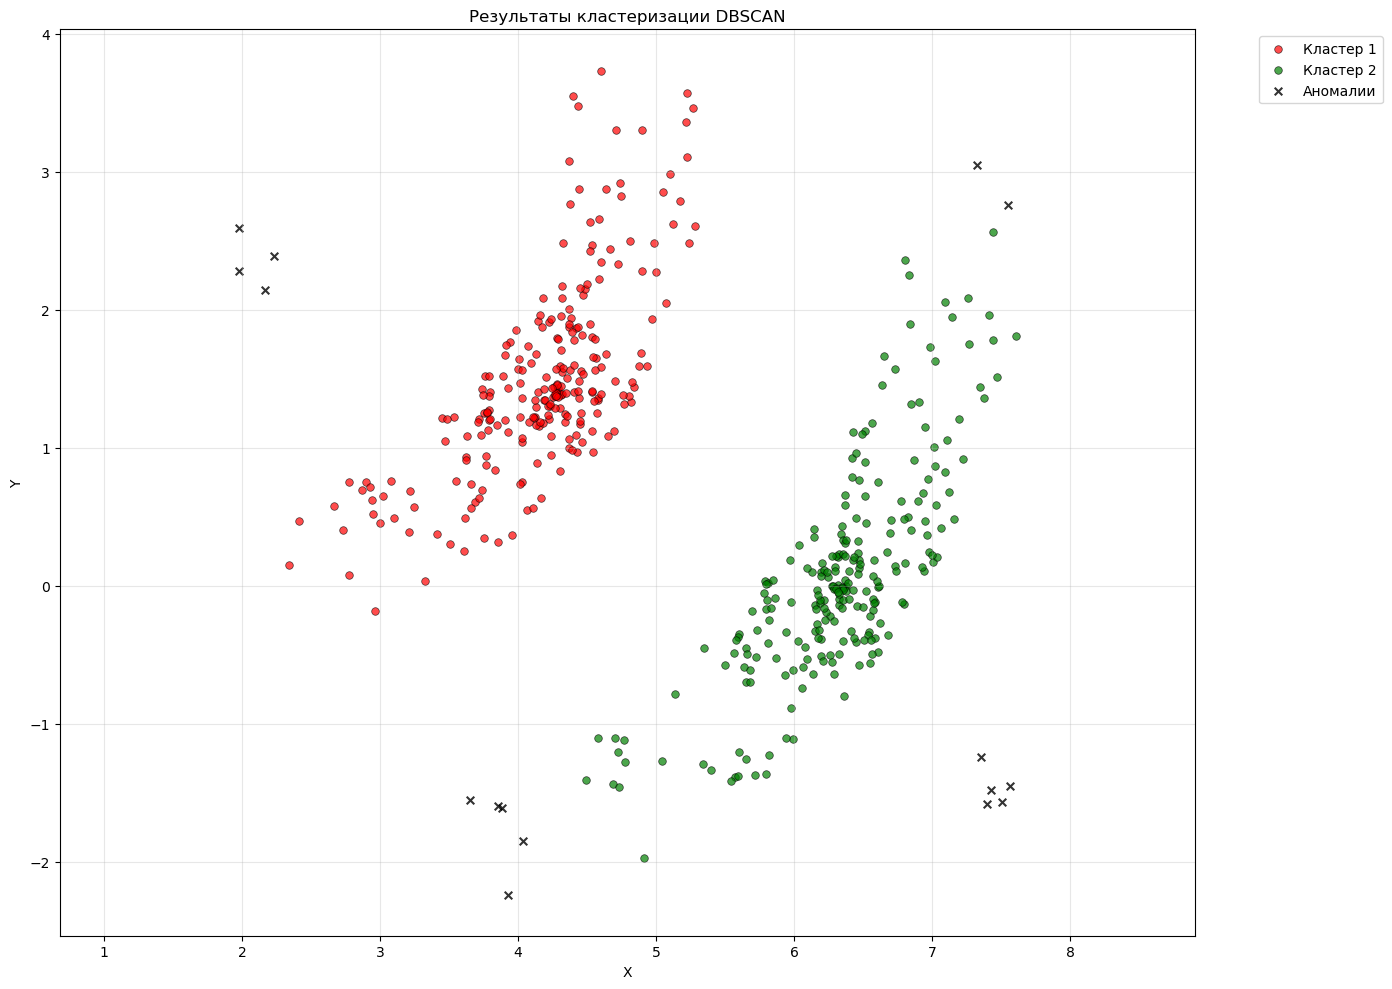

In [74]:
points = df[['X', 'Y']].values

labels = dbscann(points, eps=1, min_pts=30)

unique_labels = np.unique(labels[labels >= 1]) 
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -2)
colors = ['red', 'green', 'orange']
color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(unique_labels)}
plt.figure(figsize=(14, 10))
for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=[color_map[cluster_id]], s=30, alpha=0.7, 
                label=f'Кластер {cluster_id}', edgecolors='black', linewidth=0.5)
anomaly_points = points[labels == -2]
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            c='black', s=30, marker='x', alpha=0.8, 
            label='Аномалии')
plt.title('Результаты кластеризации DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [75]:

centroids = []
centroid_points = []

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    centroid = find_centroid_point(cluster_points)

    centroids.append(centroid)
    centroid_points.append(centroid)
    print(f"Кластер {cluster_id}: центроид = ({centroid[0]:.6f}, {centroid[1]:.6f})")

centroids_array = np.array(centroids)
mean_x = np.mean(centroids_array[:, 0])
mean_y = np.mean(centroids_array[:, 1])
result_x = mean_x * 100000
result_y = mean_y * 100000
print(f"Среднее абсцисс центроидов: {result_x:.2f}")
print(f"Среднее ординат центроидов: {result_y:.2f}")

Кластер 1: центроид = (4.244770, 1.431458)
Кластер 2: центроид = (6.345379, -0.006182)
Среднее абсцисс центроидов: 529507.47
Среднее ординат центроидов: 71263.81


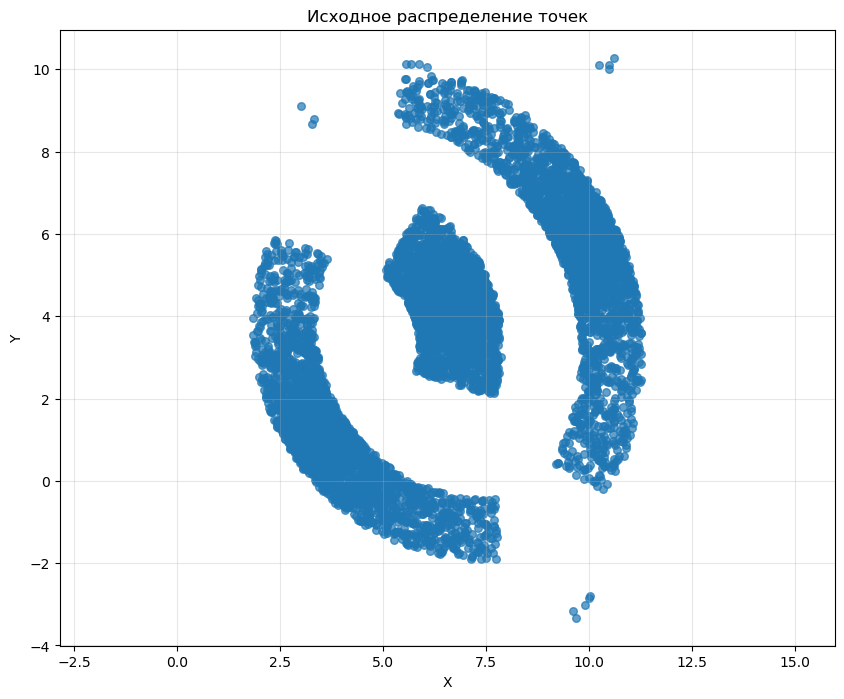

In [76]:
df = pd.read_csv('5.txt', names=['X', 'Y'])
build(df)

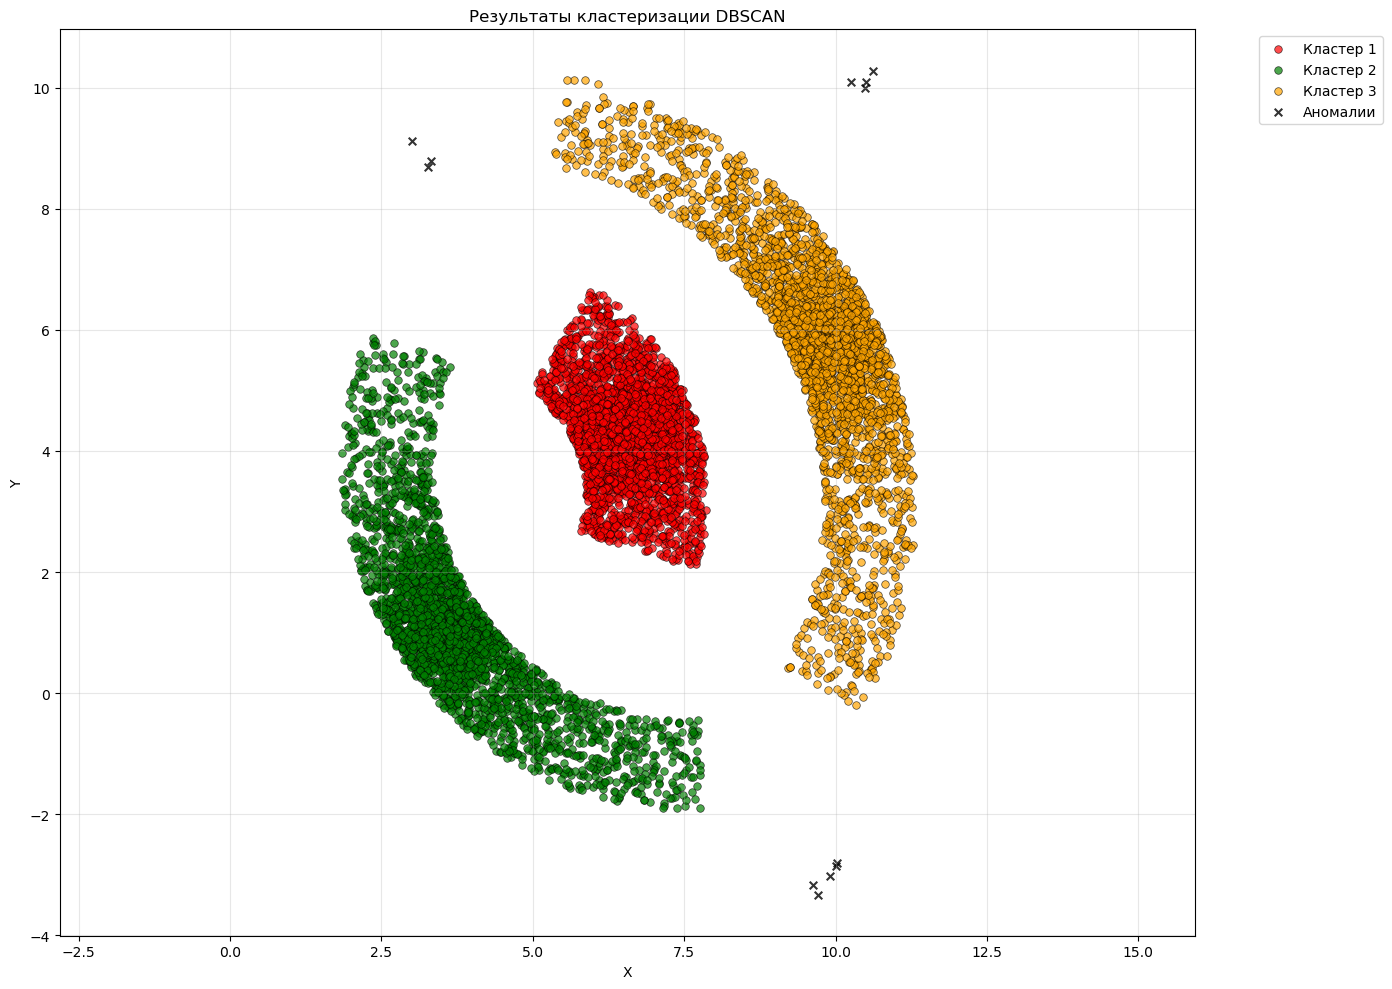

In [77]:
points = df[['X', 'Y']].values

labels = dbscann(points, eps=1, min_pts=30)


unique_labels = np.unique(labels[labels >= 1])
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -2)
colors = ['red', 'green', 'orange']
color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(unique_labels)}
plt.figure(figsize=(14, 10))
for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=[color_map[cluster_id]], s=30, alpha=0.7, 
                label=f'Кластер {cluster_id}', edgecolors='black', linewidth=0.5)
anomaly_points = points[labels == -2]
plt.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
            c='black', s=30, marker='x', alpha=0.8, 
            label='Аномалии')
plt.title('Результаты кластеризации DBSCAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [78]:

centroids = []
centroid_points = []

for cluster_id in unique_labels:
    cluster_points = points[labels == cluster_id]
    centroid = find_centroid_point(cluster_points)
    centroids.append(centroid)
    centroid_points.append(centroid)
    print(f"Кластер {cluster_id}: центроид = ({centroid[0]:.6f}, {centroid[1]:.6f})")
centroids_array = np.array(centroids)
mean_x = np.mean(centroids_array[:, 0])
mean_y = np.mean(centroids_array[:, 1])
result_x = mean_x * 100000
result_y = mean_y * 100000
print(f"Среднее абсцисс центроидов: {result_x:.2f}")
print(f"Среднее ординат центроидов: {result_y:.2f}")

Кластер 1: центроид = (6.632439, 4.292176)
Кластер 2: центроид = (3.583692, 0.999784)
Кластер 3: центроид = (9.882268, 5.829084)
Среднее абсцисс центроидов: 669946.65
Среднее ординат центроидов: 370701.48


# Кластеризация (1 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [83]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice


In [84]:
two_means = cluster.MiniBatchKMeans(n_clusters=3, random_state=42)
dbscan = cluster.DBSCAN(eps=0.3)
clustering_algorithms = (
    ("K-Means", two_means),
    ("DBSCAN", dbscan),
    ("MeanShift", ms),
    ("Spectral\nClustering", spectral),
    ("Ward", ward),
    ("Agglomerative\nClustering", average_linkage),
    ("OPTICS", optics),
    ("Gaussian\nMixture", gmm),
)


np.random.seed(0)

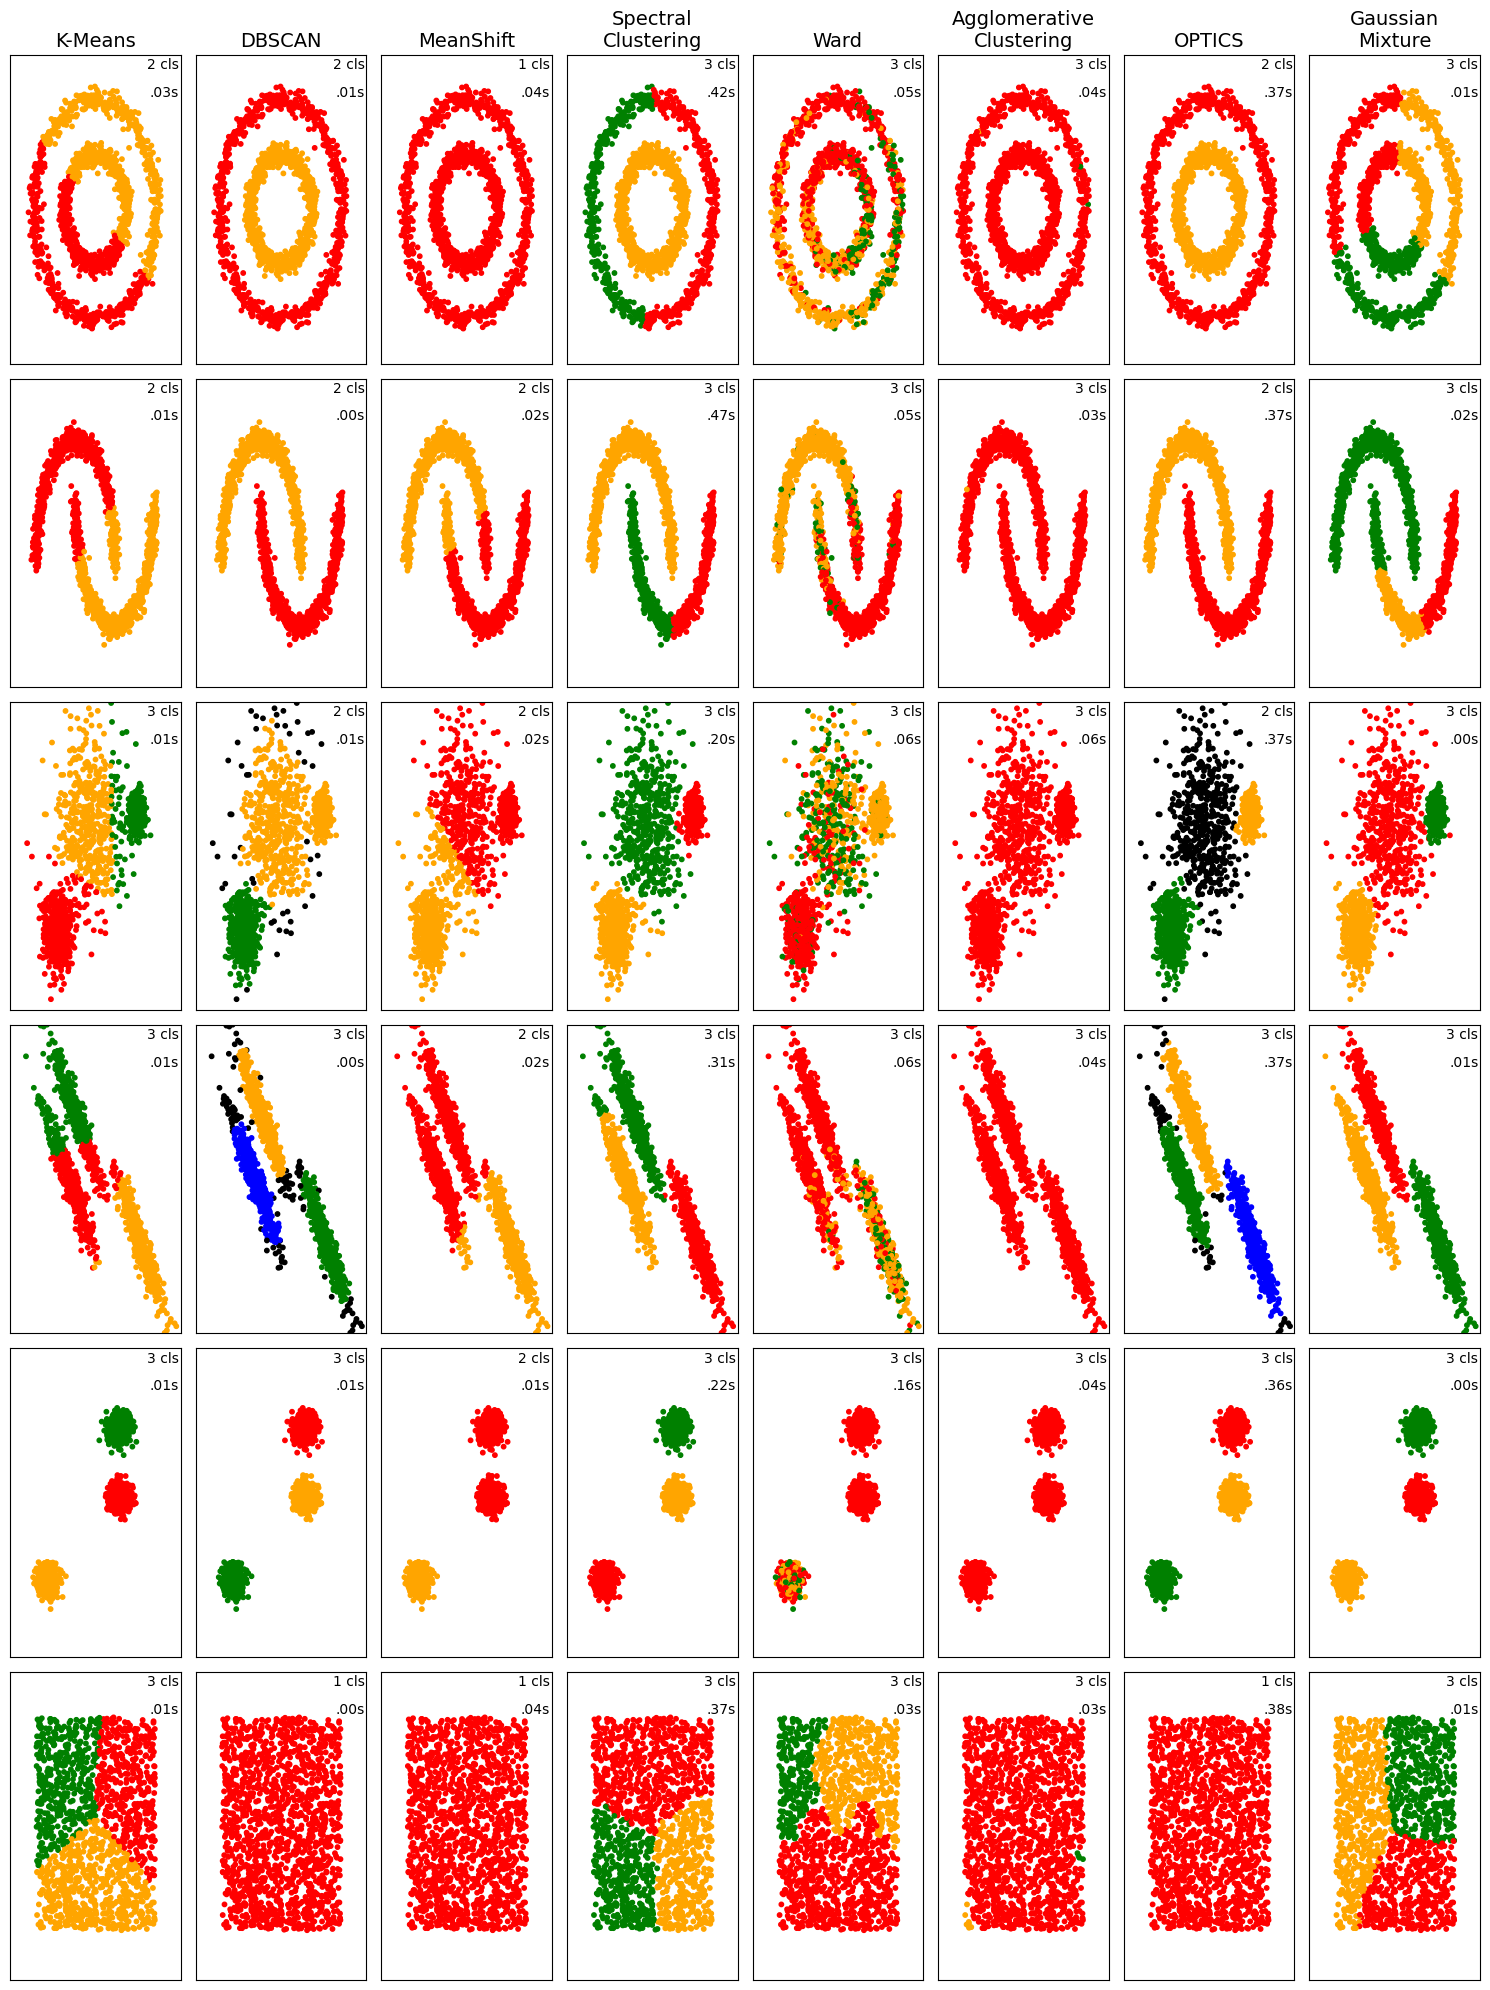

In [85]:

n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None


random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)


plt.figure(figsize=(15, 20))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.3
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 20,
            "xi": 0.25,
        },
    ),
    (noisy_moons, {"damping": 0.75, "preference": -220, "n_clusters": 2}),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 5,
            "xi": 0.035,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 20,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {}),
    (no_structure, {}),
]


ms = cluster.MeanShift(bandwidth=None, bin_seeding=True)
spectral = cluster.SpectralClustering(
    n_clusters=3, eigen_solver='arpack', affinity='nearest_neighbors', 
    random_state=42, n_init=100
)
ward = cluster.AgglomerativeClustering(
    n_clusters=3, linkage='ward', connectivity=None
)

average_linkage = cluster.AgglomerativeClustering(
    linkage="average", metric="cityblock", n_clusters=3, connectivity=None
)
optics = cluster.OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.1)
gmm = mixture.GaussianMixture(n_components=3, covariance_type='full', random_state=42)


for i_dataset, (dataset, algo_params) in enumerate(datasets):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    X = StandardScaler().fit_transform(X)

    if params["quantile"] is not None:
        bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])
        ms.set_params(bandwidth=bandwidth)

    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
 
    connectivity = 0.5 * (connectivity + connectivity.T)

    two_means.set_params(n_clusters=params["n_clusters"])
    dbscan.set_params(eps=params["eps"], min_samples=params["min_samples"])
    spectral.set_params(n_clusters=params["n_clusters"])
    ward.set_params(n_clusters=params["n_clusters"], connectivity=connectivity)
    average_linkage.set_params(n_clusters=params["n_clusters"], connectivity=connectivity)
    optics.set_params(min_samples=params["min_samples"], xi=params["xi"], 
                     min_cluster_size=params["min_cluster_size"])
    gmm.set_params(n_components=params["n_clusters"])

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        if hasattr(algorithm, "fit_predict"):
            y_pred = algorithm.fit_predict(X)
        elif hasattr(algorithm, "fit"):
            if name == "Gaussian\nMixture":
                algorithm.fit(X)
                y_pred = algorithm.predict(X)
            elif name == "Spectral\nClustering":
                algorithm.fit(X)
                y_pred = algorithm.labels_
            else:
                algorithm.fit(X)
                if hasattr(algorithm, "labels_"):
                    y_pred = algorithm.labels_.astype(int)
                else:
                    y_pred = algorithm.predict(X)
        else:
            y_pred = algorithm.fit(X).labels_.astype(int)

        
        t1 = time.time()
        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=14)
        unique_labels = np.unique(y_pred)
        n_clusters_found = len(unique_labels) - (1 if -1 in unique_labels else 0)

        colors = np.array(list(islice(cycle(['red', 'orange', 'green', 'blue', 'black']), 
                                      max(len(unique_labels), 1))))
        label_to_color = {}
        for i, label in enumerate(sorted(unique_labels)):
            if label == -1:
                label_to_color[label] = -1 
            else:
                label_to_color[label] = i
        color_indices = np.array([label_to_color[label] for label in y_pred])
        colors_for_plot = np.where(color_indices == -1, '#000000', 
                                  colors[color_indices])
        plt.scatter(X[:, 0], X[:, 1], s=10, c=colors_for_plot)
        
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(.99, .99, f'{n_clusters_found} cls',
                 transform=plt.gca().transAxes, size=10,
                 horizontalalignment='right', verticalalignment='top')
        plt.text(.99, .90, ('%.2fs' % (t1 - t0)).lstrip('0'),
                 transform=plt.gca().transAxes, size=10,
                 horizontalalignment='right', verticalalignment='top')
        plot_num += 1
plt.tight_layout()
plt.show()